# FIFA World Cup 2026 — Data Analysis & Match Predictor

In [30]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np


## Loading Data, initial operations and data cleaning

### 1. Load Results

In [31]:
df = pd.read_csv('data/results.csv')
print("Shape of the DataFrame:", df.shape)
df.head()

Shape of the DataFrame: (49378, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### 2. Basic OPerations

In [32]:
print("Columns in the DataFrame:", df.columns)
print("Data types of each column:\n", df.dtypes)
print("Summary statistics of the DataFrame:\n", df.describe())
print("Number of unique values in each column:\n", df.nunique())
print("Number of missing values in each column:\n", df.isnull().sum())


Columns in the DataFrame: Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='str')
Data types of each column:
 date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
dtype: object
Summary statistics of the DataFrame:
          home_score    away_score
count  49306.000000  49306.000000
mean       1.757393      1.182209
std        1.774934      1.402759
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     21.000000
Number of unique values in each column:
 date          16463
home_team       327
away_team       321
home_score       26
away_score       22
tournament      199
city           2139
country         269
neutral           2
dtype: int64
Number of missin

In [33]:
print("Top 30 tournaments in the dataset:")
print(df['tournament'].value_counts().head(30))

Top 30 tournaments in the dataset:
tournament
Friendly                                18301
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
COSAFA Cup                        

In [34]:
df['date'] = pd.to_datetime(df['date'])
print("Oldest match date:", df['date'].min())
print("Most recent match date:", df['date'].max())
print("Unique teams in the dataset:", df['home_team'].nunique() + df['away_team'].nunique())

Oldest match date: 1872-11-30 00:00:00
Most recent match date: 2026-06-27 00:00:00
Unique teams in the dataset: 648


###  3. Get only the competitive matches since 2018

In [35]:
competitive_tournaments = [
    'FIFA World Cup',
    'FIFA World Cup qualification',
    'UEFA Euro qualification',
    'UEFA Euro',
    'UEFA Nations League',
    'African Cup of Nations qualification',
    'African Cup of Nations',
    'Copa América',
    'AFC Asian Cup qualification',
    'AFC Asian Cup',
    'CONCACAF Nations League',
    'Gold Cup',
    'Arab Cup',
    'Gulf Cup'
]
df_2018 = df[df['date'] >= '2018-01-01']
df_competitive = df_2018[df_2018['tournament'].isin(competitive_tournaments)]

print(f"Total matches since 2018: {len(df_2018)}")
print(f"After removing friendlies/minor tournaments: {len(df_competitive)}")
print(f"\nBreakdown:")
print(df_competitive['tournament'].value_counts())

Total matches since 2018: 8081
After removing friendlies/minor tournaments: 4959

Breakdown:
tournament
FIFA World Cup qualification            1767
UEFA Nations League                      658
African Cup of Nations qualification     560
UEFA Euro qualification                  501
CONCACAF Nations League                  422
African Cup of Nations                   208
FIFA World Cup                           200
Gold Cup                                 124
AFC Asian Cup qualification              118
AFC Asian Cup                            102
UEFA Euro                                102
Copa América                              86
Arab Cup                                  63
Gulf Cup                                  48
Name: count, dtype: int64


### 4. Check if there is enough data for WC 2026 Teams

In [36]:
all_teams = pd.concat([df_competitive['home_team'], df_competitive['away_team']]).unique()

print("\nAll teams in competitive dataset:")
print(sorted(all_teams))


All teams in competitive dataset:
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chile', 'China PR', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czech Republic', 'DR Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'French Guiana', 'Gabon', 'Gambia', 'Georgia', 'Germany'

In [37]:
wc_2026_teams = [
    'Argentina', 'Australia', 'Austria', 'Algeria',
    'Belgium', 'Bosnia and Herzegovina', 'Brazil',
    'Canada', 'Cape Verde', 'Colombia', 'DR Congo', 'Croatia',
    'Curaçao', 'Czech Republic',
    'Egypt', 'Ecuador', 'England',
    'France',
    'Germany', 'Ghana',
    'Haiti',
    'Iran', 'Iraq', 'Ivory Coast',
    'Japan', 'Jordan',
    'Mexico', 'Morocco',
    'Netherlands', 'New Zealand', 'Norway',
    'Panama', 'Paraguay', 'Portugal',
    'Qatar',
    'Saudi Arabia', 'Scotland', 'Senegal',
    'South Africa', 'South Korea', 'Spain',
    'Sweden', 'Switzerland',
    'Tunisia', 'Turkey',
    'Uruguay', 'United States', 'Uzbekistan'
]

print(f"{'Team':<20} {'Matches':>10}")
print("-" * 32)
for team in wc_2026_teams:
    matches = df_competitive[
        (df_competitive['home_team'] == team) |
        (df_competitive['away_team'] == team)
    ]
    flag = " LOW" if len(matches) < 25 else ""
    print(f"{team:<20} {len(matches):>10}{flag}")

Team                    Matches
--------------------------------
Argentina                    68
Australia                    56
Austria                      72
Algeria                      72
Belgium                      82
Bosnia and Herzegovina         65
Brazil                       65
Canada                       65
Cape Verde                   51
Colombia                     60
DR Congo                     62
Croatia                      84
Curaçao                      44
Czech Republic               68
Egypt                        78
Ecuador                      54
England                      87
France                       87
Germany                      68
Ghana                        55
Haiti                        52
Iran                         55
Iraq                         70
Ivory Coast                  63
Japan                        59
Jordan                       52
Mexico                       71
Morocco                      80
Netherlands                  80
New Z

### 5. Save dataset with competitive matches since 2018

In [38]:
df_competitive.to_csv('data/competitive_matches.csv', index=False)
print(df_competitive.shape)
df_competitive.head()


(4959, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41297,2018-01-02,Iraq,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41298,2018-01-02,Oman,Bahrain,1.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41299,2018-01-05,Oman,United Arab Emirates,0.0,0.0,Gulf Cup,Kuwait City,Kuwait,True
41332,2018-03-22,Kyrgyzstan,Myanmar,5.0,1.0,AFC Asian Cup qualification,Incheon,South Korea,True
41403,2018-03-27,Afghanistan,Cambodia,2.0,1.0,AFC Asian Cup qualification,Dushanbe,Tajikistan,True


### 6. Fetch WC 2026 Fixtures 

In [39]:
load_dotenv()
API_KEY = os.getenv("API_KEY")
headers = {"X-Auth-Token": API_KEY}

r = requests.get(
    "https://api.football-data.org/v4/competitions/WC/matches",
    headers=headers,
    timeout=10
)

print(f"Status code: {r.status_code}")
data = r.json()
print(f"Keys in response: {list(data.keys())}")

Status code: 200
Keys in response: ['filters', 'resultSet', 'competition', 'matches']


In [40]:
fixtures = pd.DataFrame(data['matches'])
fixtures.head()

,area,competition,season,id,utcDate,status,matchday,stage,group,lastUpdated,homeTeam,awayTeam,score,odds,referees
0,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537327,2026-06-11T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_A,2026-06-11T00:20:16Z,"{'id': 769, 'name': 'Mexico', 'shortName': 'Me...","{'id': 774, 'name': 'South Africa', 'shortName...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,"[{'id': 11412, 'name': 'Wilton Sampaio', 'type..."
1,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537328,2026-06-12T02:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_A,2026-06-11T00:20:16Z,"{'id': 772, 'name': 'South Korea', 'shortName'...","{'id': 798, 'name': 'Czechia', 'shortName': 'C...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,"[{'id': 276653, 'name': 'Amin Omar', 'type': '..."
2,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537333,2026-06-12T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_B,2026-06-11T00:20:16Z,"{'id': 828, 'name': 'Canada', 'shortName': 'Ca...","{'id': 1060, 'name': 'Bosnia-Herzegovina', 'sh...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,"[{'id': 57301, 'name': 'Facundo Tello', 'type'..."
3,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537345,2026-06-13T01:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_D,2026-06-11T00:20:16Z,"{'id': 771, 'name': 'United States', 'shortNam...","{'id': 761, 'name': 'Paraguay', 'shortName': '...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,"[{'id': 43899, 'name': 'Danny Makkelie', 'type..."
4,"{'id': 2267, 'name': 'World', 'code': 'INT', '...","{'id': 2000, 'name': 'FIFA World Cup', 'code':...","{'id': 2398, 'startDate': '2026-06-11', 'endDa...",537334,2026-06-13T19:00:00Z,TIMED,1.0,GROUP_STAGE,GROUP_B,2026-06-11T00:20:16Z,"{'id': 8030, 'name': 'Qatar', 'shortName': 'Qa...","{'id': 788, 'name': 'Switzerland', 'shortName'...","{'winner': None, 'duration': 'REGULAR', 'fullT...",{'msg': 'Activate Odds-Package in User-Panel t...,"[{'id': 190002, 'name': 'Said Martinez', 'type..."


In [41]:
fixtures[['utcDate', 'homeTeam', 'awayTeam', 'status']].head(10)

,utcDate,homeTeam,awayTeam,status
0,2026-06-11T19:00:00Z,"{'id': 769, 'name': 'Mexico', 'shortName': 'Me...","{'id': 774, 'name': 'South Africa', 'shortName...",TIMED
1,2026-06-12T02:00:00Z,"{'id': 772, 'name': 'South Korea', 'shortName'...","{'id': 798, 'name': 'Czechia', 'shortName': 'C...",TIMED
2,2026-06-12T19:00:00Z,"{'id': 828, 'name': 'Canada', 'shortName': 'Ca...","{'id': 1060, 'name': 'Bosnia-Herzegovina', 'sh...",TIMED
3,2026-06-13T01:00:00Z,"{'id': 771, 'name': 'United States', 'shortNam...","{'id': 761, 'name': 'Paraguay', 'shortName': '...",TIMED
4,2026-06-13T19:00:00Z,"{'id': 8030, 'name': 'Qatar', 'shortName': 'Qa...","{'id': 788, 'name': 'Switzerland', 'shortName'...",TIMED
5,2026-06-13T22:00:00Z,"{'id': 764, 'name': 'Brazil', 'shortName': 'Br...","{'id': 815, 'name': 'Morocco', 'shortName': 'M...",TIMED
6,2026-06-14T01:00:00Z,"{'id': 836, 'name': 'Haiti', 'shortName': 'Hai...","{'id': 8873, 'name': 'Scotland', 'shortName': ...",TIMED
7,2026-06-14T04:00:00Z,"{'id': 779, 'name': 'Australia', 'shortName': ...","{'id': 803, 'name': 'Turkey', 'shortName': 'Tu...",TIMED
8,2026-06-14T17:00:00Z,"{'id': 759, 'name': 'Germany', 'shortName': 'G...","{'id': 9460, 'name': 'Curaçao', 'shortName': '...",TIMED
9,2026-06-14T20:00:00Z,"{'id': 8601, 'name': 'Netherlands', 'shortName...","{'id': 766, 'name': 'Japan', 'shortName': 'Jap...",TIMED


In [42]:
import ast

fixtures = pd.read_csv('data/wc_2026_fixtures.csv')

fixtures['home_name'] = fixtures['homeTeam'].apply(
    lambda x: ast.literal_eval(x)['name'] if isinstance(x, str) else x['name']
)
fixtures['away_name'] = fixtures['awayTeam'].apply(
    lambda x: ast.literal_eval(x)['name'] if isinstance(x, str) else x['name']
)

print("Parsed. Columns now:", fixtures.columns.tolist())
print(fixtures['home_name'].head(5))

Parsed. Columns now: ['area', 'competition', 'season', 'id', 'utcDate', 'status', 'matchday', 'stage', 'group', 'lastUpdated', 'homeTeam', 'awayTeam', 'score', 'odds', 'referees', 'home_name', 'away_name']
0           Mexico
1      South Korea
2           Canada
3    United States
4            Qatar
Name: home_name, dtype: str


In [43]:
api_to_dataset = {
    'Bosnia-Herzegovina':  'Bosnia and Herzegovina',
    'Cape Verde Islands':  'Cape Verde',
    'Congo DR':            'DR Congo',
    'Czechia':             'Czech Republic',
}

fixtures['home_name'] = fixtures['home_name'].replace(api_to_dataset)
fixtures['away_name'] = fixtures['away_name'].replace(api_to_dataset)

# Save clean fixtures
fixtures.to_csv('data/wc_2026_fixtures.csv', index=False)
print(f"Fixtures saved: {len(fixtures)} matches")
# Verify — these 4 should not appear anymore
check = pd.concat([fixtures['home_name'], fixtures['away_name']]).dropna().unique()
print(sorted(check))

print(f"\nMatches by stage:")
print(fixtures['stage'].value_counts())

Fixtures saved: 104 matches
['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia', 'Croatia', 'Curaçao', 'Czech Republic', 'DR Congo', 'Ecuador', 'Egypt', 'England', 'France', 'Germany', 'Ghana', 'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Japan', 'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Paraguay', 'Portugal', 'Qatar', 'Saudi Arabia', 'Scotland', 'Senegal', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey', 'United States', 'Uruguay', 'Uzbekistan']

Matches by stage:
stage
GROUP_STAGE       72
LAST_32           16
LAST_16            8
QUARTER_FINALS     4
SEMI_FINALS        2
THIRD_PLACE        1
FINAL              1
Name: count, dtype: int64


## Data Loading and initial cleaning DONE

- Loaded the matches from 1872 to 2026
- Made new dataset with competitive matches since 2018(Relevant for analysis)
- Fetched WC 2026 Fixtures


| Item | Result |
|------|--------|
| Total dataset size | 49378 matches |
| Competitive matches since 2018 | 4959 matches |
| Teams with low data (< 25 matches) | 1 team |
| WC 2026 fixtures fetched | 104 matches |




## Exploratory Data Analysis

### 1. Average Goals Per Match

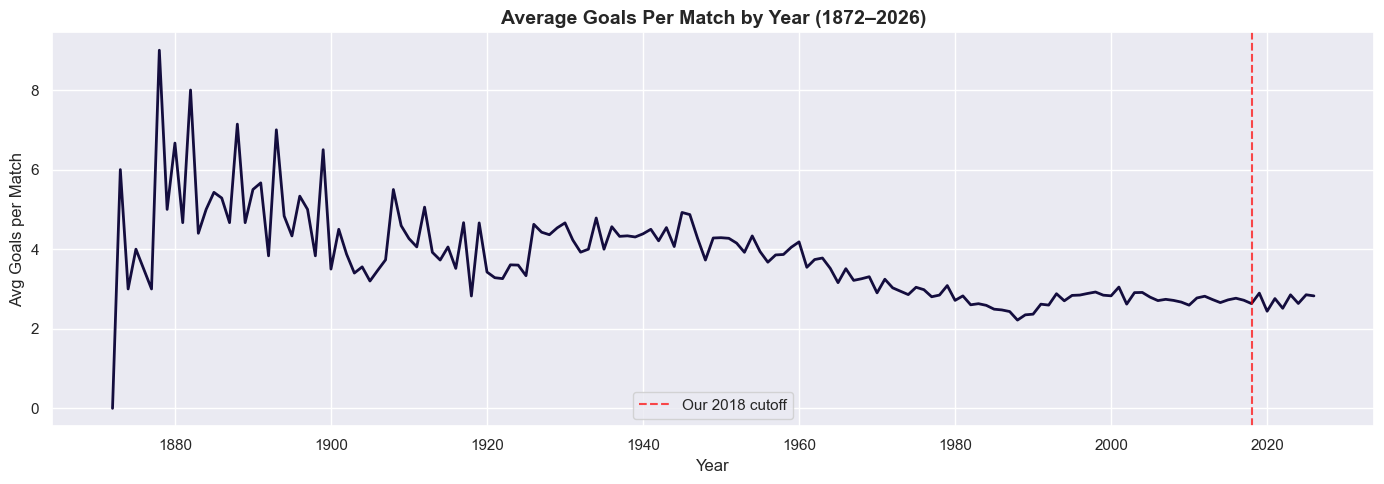

In [44]:
sns.set_theme(style='darkgrid')

df['year'] = df['date'].dt.year
goals_by_decade = df.copy()
goals_by_decade['total_goals'] = df['home_score'] + df['away_score']
goals_per_year = goals_by_decade.groupby('year')['total_goals'].mean()

plt.figure(figsize=(14, 5))
sns.lineplot(x=goals_per_year.index, y=goals_per_year.values, color='#140d3e', linewidth=2)
plt.title('Average Goals Per Match by Year (1872–2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Avg Goals per Match')
plt.axvline(x=2018, color='red', linestyle='--', alpha=0.7, label='Our 2018 cutoff')
plt.legend()
plt.tight_layout()
plt.savefig('charts/goals_per_year.png', dpi=150)
plt.show()

### 2. Home Win/Draw/loss Split since 2018

In [45]:
df_competitive['home_result'] = df_competitive.apply(
    lambda r: 'win'  if r['home_score'] > r['away_score']
    else      'draw' if r['home_score'] == r['away_score']
    else      'loss', axis=1
)

print("Result distribution (all matches):")
print(df_competitive['home_result'].value_counts())

Result distribution (all matches):
home_result
win     2277
loss    1593
draw    1089
Name: count, dtype: int64


Win/Draw/Loss split in competitive matches since 2018:
home_result
draw    22.0
loss    32.1
win     45.9
dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_13744\436105907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rates.index, y=win_rates.values, palette=['#1db954', '#555555', '#e63946'])


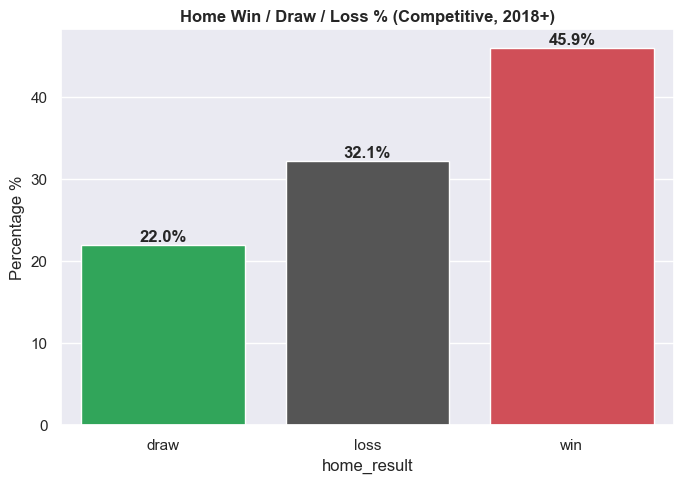

In [46]:
win_rates = df_competitive.groupby('home_result').size() / len(df_competitive) * 100
print("Win/Draw/Loss split in competitive matches since 2018:")
print(win_rates.round(1))

plt.figure(figsize=(7, 5))
sns.barplot(x=win_rates.index, y=win_rates.values, palette=['#1db954', '#555555', '#e63946'])
plt.title('Home Win / Draw / Loss % (Competitive, 2018+)', fontweight='bold')
plt.ylabel('Percentage %')
for i, val in enumerate(win_rates.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/home_win_rate.png', dpi=150)
plt.show()

### 3. Goals Per Game (Top 15 Teams)

C:\Users\HP\AppData\Local\Temp\ipykernel_13744\1751171892.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='goals_per_game', y='team', data=goals_df.head(15), palette='Greens_r')


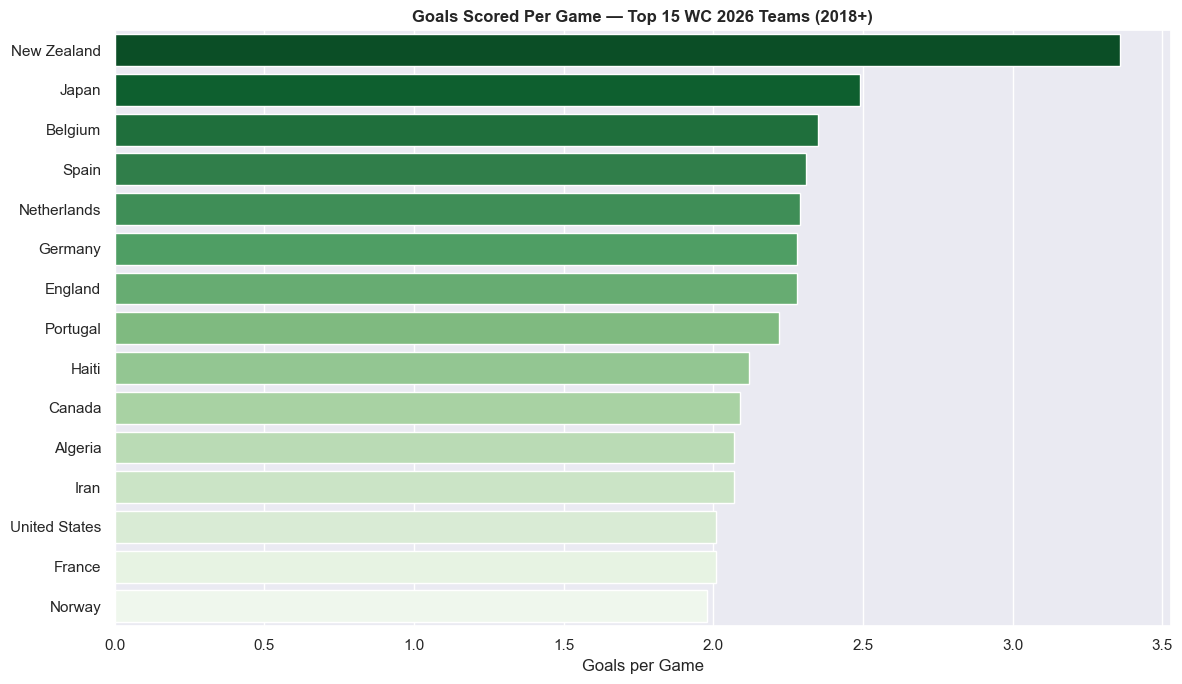

In [47]:
goals_scored = []
for team in wc_2026_teams:
    home_goals = df_competitive[df_competitive['home_team'] == team]['home_score'].sum()
    away_goals = df_competitive[df_competitive['away_team'] == team]['away_score'].sum()
    total_matches = len(df_competitive[
        (df_competitive['home_team'] == team) |
        (df_competitive['away_team'] == team)
    ])
    if total_matches > 0:
        goals_scored.append({
            'team': team,
            'goals_per_game': round((home_goals + away_goals) / total_matches, 2)
        })

goals_df = pd.DataFrame(goals_scored).sort_values('goals_per_game', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='goals_per_game', y='team', data=goals_df.head(15), palette='Greens_r')
plt.title('Goals Scored Per Game — Top 15 WC 2026 Teams (2018+)', fontweight='bold')
plt.xlabel('Goals per Game')
plt.ylabel('')
plt.tight_layout()
plt.savefig('charts/goals_per_game.png', dpi=150)
plt.show()

## Feature Engineering

### 1. FIFA Rankings

In [48]:

fifa_rankings = {
    'Argentina':              1,
    'France':                 3,
    'Spain':                  2,
    'England':                4,
    'Brazil':                 6,
    'Portugal':               5,
    'Netherlands':            8,
    'Belgium':                9,
    'Germany':                10,
    'Uruguay':               10,
    'Colombia':              13,
    'Morocco':               7,
    'Japan':                 13,
    'Croatia':               11,
    'United States':         15,
    'Mexico':                14,
    'Senegal':               15,
    'Switzerland':           19,
    'Iran':                  20,
    'South Korea':           25,
    'Denmark':               21,
    'Austria':               23,
    'Turkey':                22,
    'Ecuador':               24,
    'Australia':             27,
    'Norway':                31,
    'Egypt':                 29,
    'Algeria':               28,
    'Canada':                30,
    'Tunisia':               46,
    'Sweden':                38,
    'Paraguay':              41,
    'Scotland':              43,
    'Ivory Coast':           33,
    'Czech Republic':        39,
    'South Africa':          60,
    'DR Congo':              45,
    'Ghana':                 73,
    'Qatar':                 55,
    'Saudi Arabia':          61,
    'Panama':                34,
    'Iraq':                  56,
    'Jordan':                63,
    'Cape Verde':            68,
    'New Zealand':           85,
    'Uzbekistan':            50,
    'Bosnia and Herzegovina':64,
    'Curaçao':               83,
    'Haiti':                 81,
}

### 2. Team Features Function

In [49]:

def team_features(team_name, df, fifa_rankings, n_matches=40):
    home = df[df['home_team'] == team_name].copy()
    away = df[df['away_team'] == team_name].copy()

    home['goals_for']     = home['home_score']
    home['goals_against'] = home['away_score']
    home['won']           = home['home_score'] > home['away_score']

    away['goals_for']     = away['away_score']
    away['goals_against'] = away['home_score']
    away['won']           = away['away_score'] > away['home_score']

    combined = pd.concat([home, away]).sort_values('date').tail(n_matches)

    total = len(combined)
    if total == 0:
        return None

    win_rate       = combined['won'].sum() / total
    goals_scored   = combined['goals_for'].sum() / total
    goals_conceded = combined['goals_against'].sum() / total
    goal_diff      = goals_scored - goals_conceded
    ranking        = fifa_rankings.get(team_name, 50)  

    return {
        'team':              team_name,
        'matches_used':      total,
        'win_rate':          round(win_rate, 3),
        'goals_scored_pg':   round(goals_scored, 3),
        'goals_conceded_pg': round(goals_conceded, 3),
        'goal_diff':         round(goal_diff, 3),
        'fifa_ranking':      ranking,
    }

In [50]:
df_competitive = df_competitive.dropna(subset=['home_score', 'away_score'])
print(f"Rows after dropping unplayed matches: {len(df_competitive)}")


features_list = [team_features(t, df_competitive, fifa_rankings) for t in wc_2026_teams]
features_df = pd.DataFrame([f for f in features_list if f is not None])

max_rank = features_df['fifa_ranking'].max()
features_df['ranking_score'] = round(1 - (features_df['fifa_ranking'] - 1) / max_rank, 3)

features_df = features_df.sort_values('fifa_ranking').reset_index(drop=True)
print(features_df[['team', 'win_rate', 'goal_diff', 'ranking_score', 'matches_used']].to_string(index=False))

Rows after dropping unplayed matches: 4887
                  team  win_rate  goal_diff  ranking_score  matches_used
             Argentina     0.675      1.150          1.000            40
                 Spain     0.725      1.725          0.988            40
                France     0.650      1.325          0.976            40
               England     0.625      1.450          0.965            40
              Portugal     0.675      1.750          0.953            40
                Brazil     0.525      0.900          0.941            40
               Morocco     0.750      1.700          0.929            40
           Netherlands     0.575      1.225          0.918            40
               Belgium     0.475      1.025          0.906            40
               Uruguay     0.425      0.425          0.894            40
               Germany     0.575      1.600          0.894            40
               Croatia     0.550      0.900          0.882            40
        

In [51]:
# New Zealand has only 22 matches — flag it so we know prediction is less reliable
nz = features_df[features_df['team'] == 'New Zealand']
print("New Zealand features:")
print(nz.to_string(index=False))
print(f"\nNote: only {nz['matches_used'].values[0]} matches used — lower confidence prediction")

New Zealand features:
       team  matches_used  win_rate  goals_scored_pg  goals_conceded_pg  goal_diff  fifa_ranking  ranking_score
New Zealand            11     0.909            4.273              0.273        4.0            85          0.012

Note: only 11 matches used — lower confidence prediction


In [52]:
features_df.to_csv('data/team_features.csv', index=False)
print("Saved: data/team_features.csv")

Saved: data/team_features.csv


### Visualising the Features of 48 WC 2026 Teams

### 1. Win Rate Bar Chart

C:\Users\HP\AppData\Local\Temp\ipykernel_13744\713972794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_rate', y='team',


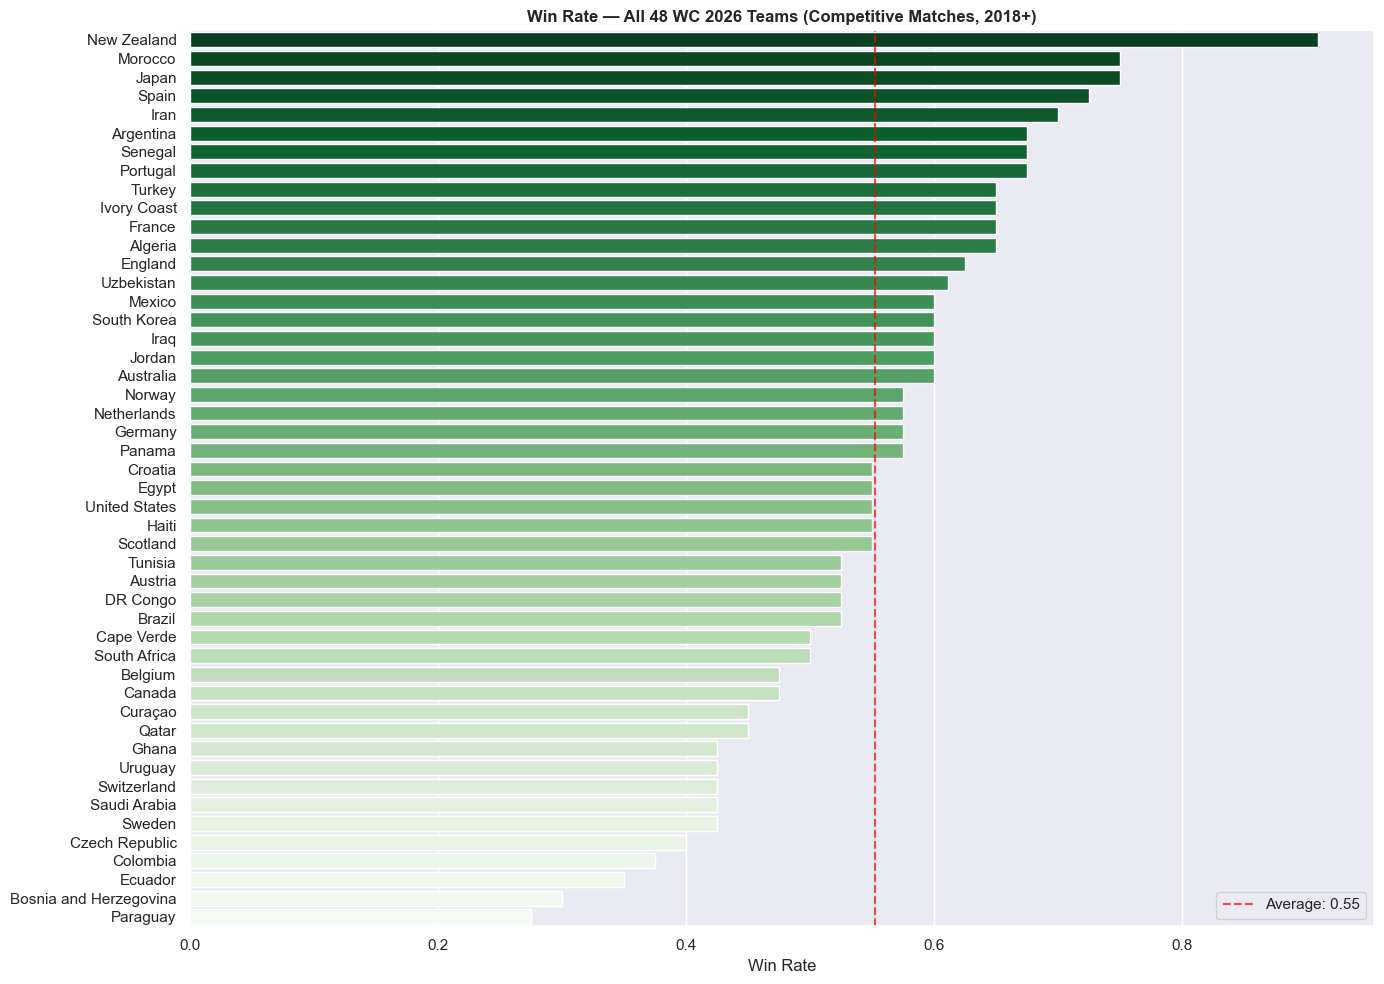

In [53]:
plt.figure(figsize=(14, 10))
sns.barplot(x='win_rate', y='team', 
            data=features_df.sort_values('win_rate', ascending=False), 
            palette='Greens_r')
plt.title('Win Rate — All 48 WC 2026 Teams (Competitive Matches, 2018+)', fontweight='bold')
plt.xlabel('Win Rate')
plt.ylabel('')
plt.axvline(x=features_df['win_rate'].mean(), color='red', linestyle='--',
            alpha=0.7, label=f"Average: {features_df['win_rate'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('charts/win_rates.png', dpi=150)
plt.show()

### 2. Goal Difference Per Game

C:\Users\HP\AppData\Local\Temp\ipykernel_13744\2159230074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='goal_diff', y='team', data=goal_diff_sorted, palette=colors)


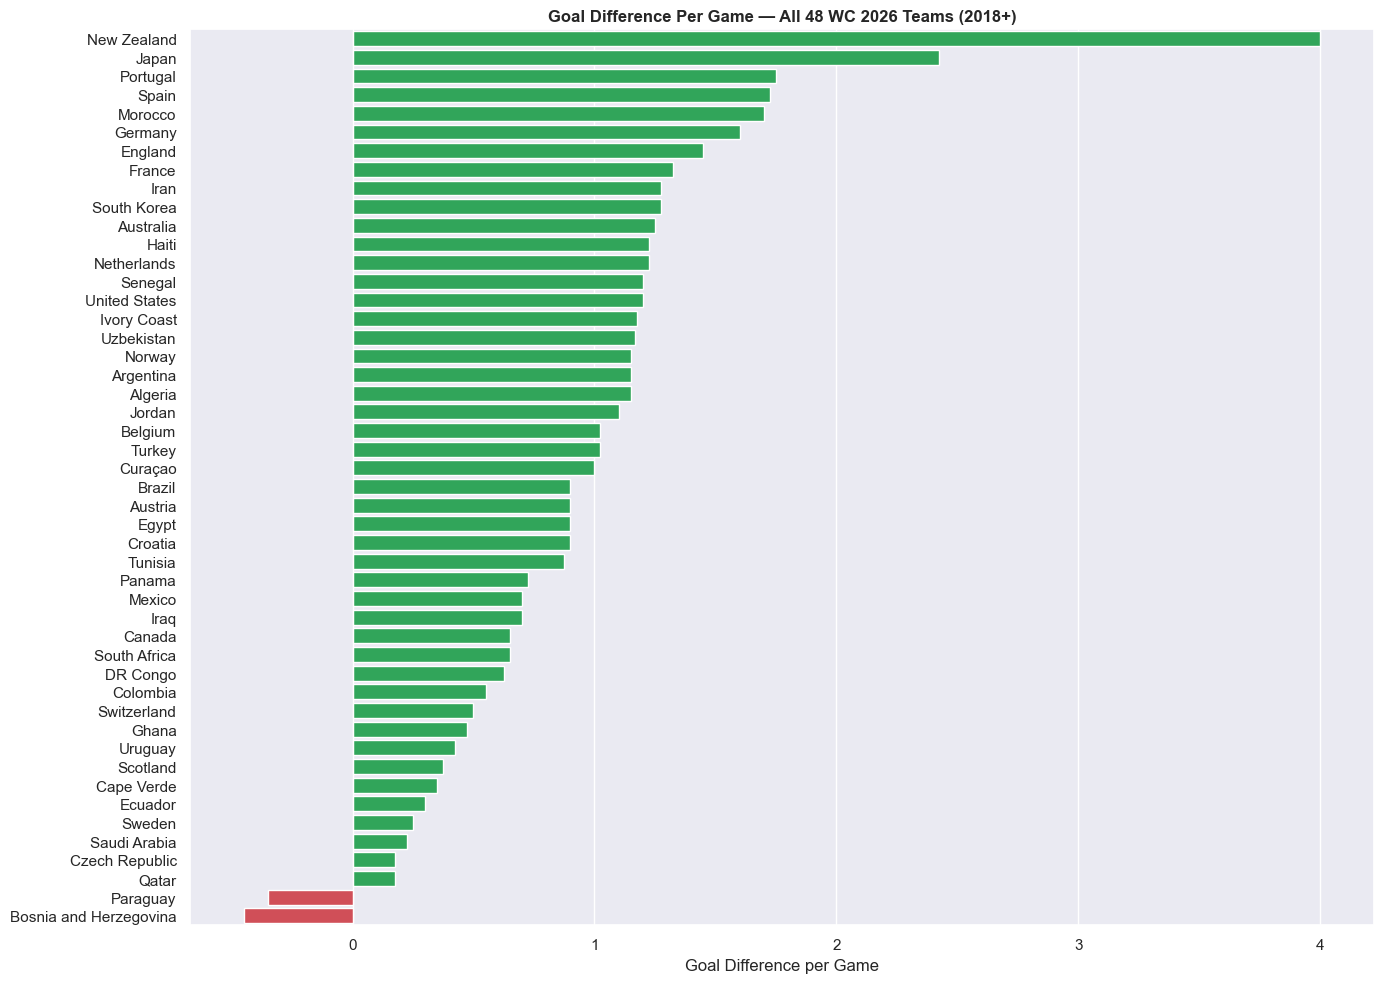

In [54]:
goal_diff_sorted = features_df.sort_values('goal_diff', ascending=False)

plt.figure(figsize=(14, 10))
colors = ['#1db954' if x > 0 else '#e63946' for x in goal_diff_sorted['goal_diff']]
sns.barplot(x='goal_diff', y='team', data=goal_diff_sorted, palette=colors)
plt.title('Goal Difference Per Game — All 48 WC 2026 Teams (2018+)', fontweight='bold')
plt.xlabel('Goal Difference per Game')
plt.ylabel('')
plt.axvline(x=0, color='white', linewidth=0.8)
plt.tight_layout()
plt.savefig('charts/goal_difference.png', dpi=150)
plt.show()

### 3. Win Rate vs Goal Difference Scatterplot

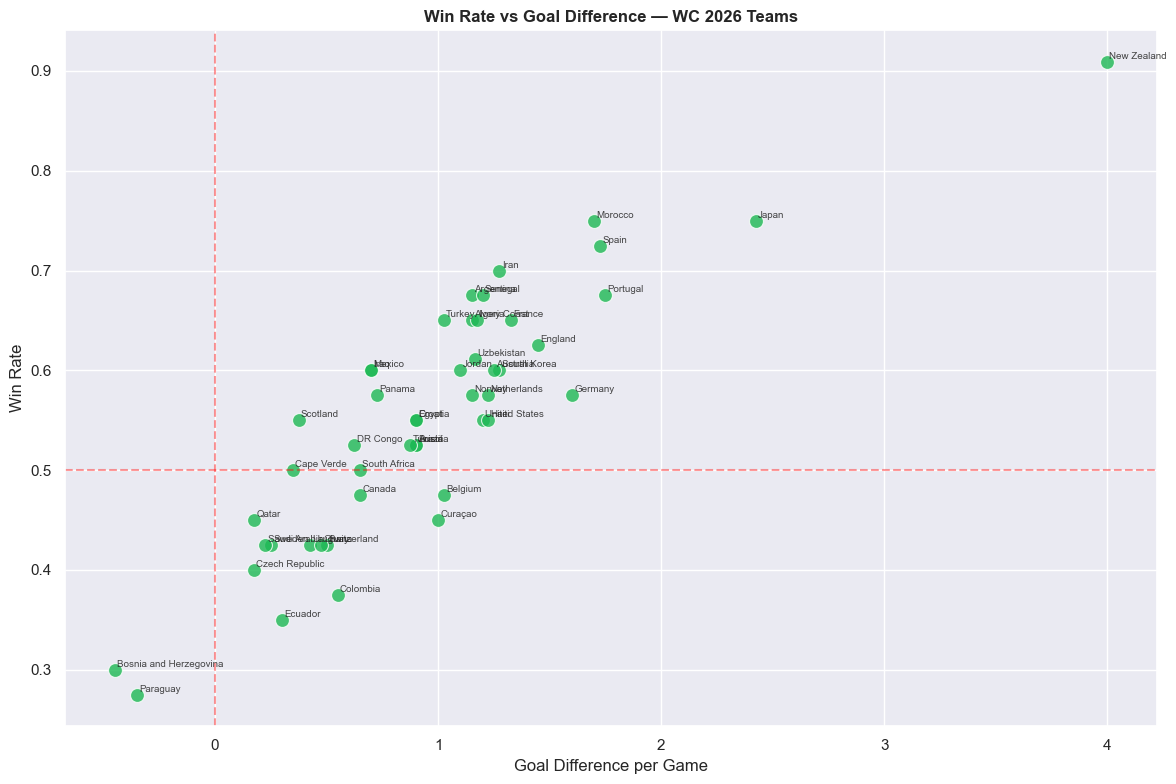

In [55]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=features_df,
    x='goal_diff',
    y='win_rate',
    s=100,
    color='#1db954',
    alpha=0.8
)

for _, row in features_df.iterrows():
    plt.text(row['goal_diff'] + 0.01, row['win_rate'] + 0.003, 
             row['team'], fontsize=7, alpha=0.85)

plt.title('Win Rate vs Goal Difference — WC 2026 Teams', fontweight='bold')
plt.xlabel('Goal Difference per Game')
plt.ylabel('Win Rate')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.axvline(x=0,   color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/winrate_vs_goaldiff.png', dpi=150)
plt.show()

### 4. FIFA Ranking vs Win Rate

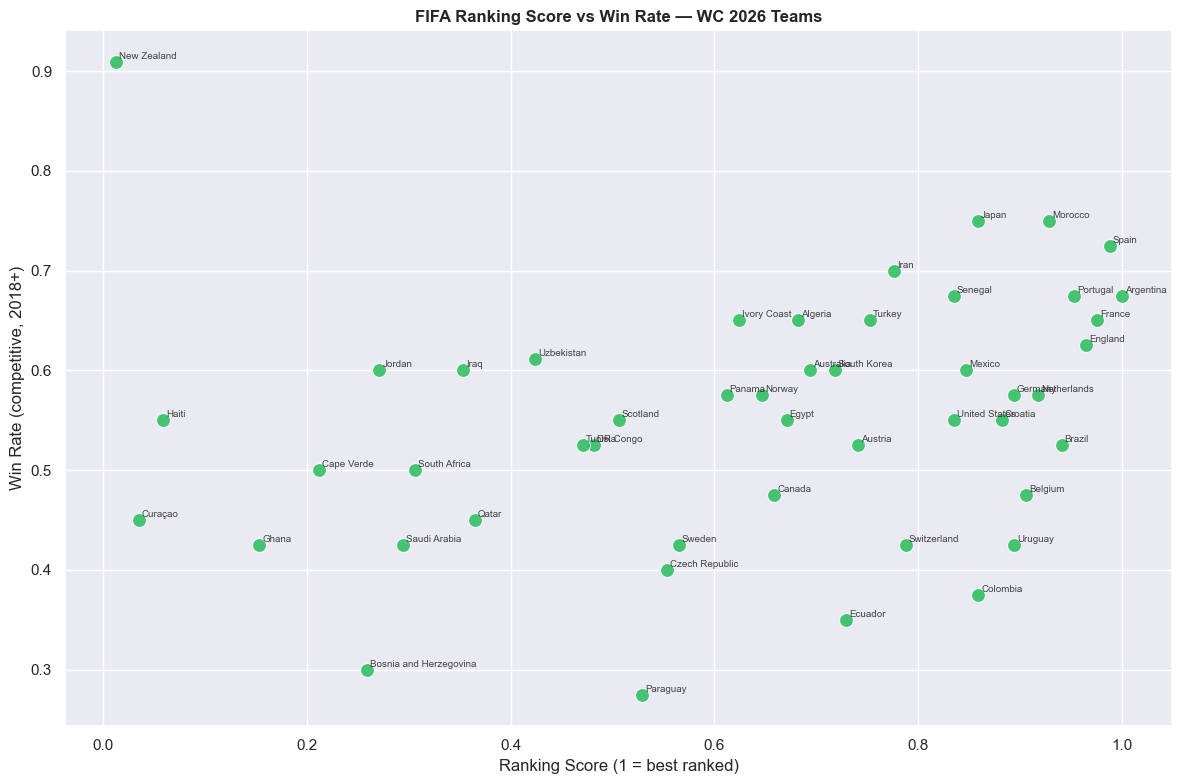

In [56]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=features_df,
    x='ranking_score',
    y='win_rate',
    s=100,
    color='#1db954',
    alpha=0.8
)

for _, row in features_df.iterrows():
    plt.text(row['ranking_score'] + 0.003, row['win_rate'] + 0.003,
             row['team'], fontsize=7, alpha=0.85)

plt.title('FIFA Ranking Score vs Win Rate — WC 2026 Teams', fontweight='bold')
plt.xlabel('Ranking Score (1 = best ranked)')
plt.ylabel('Win Rate (competitive, 2018+)')
plt.tight_layout()
plt.savefig('charts/ranking_vs_winrate.png', dpi=150)
plt.show()

In [57]:
print(features_df[['team', 'win_rate', 'goal_diff', 'ranking_score']].sort_values('ranking_score', ascending=False).head(15).to_string(index=False))

       team  win_rate  goal_diff  ranking_score
  Argentina     0.675      1.150          1.000
      Spain     0.725      1.725          0.988
     France     0.650      1.325          0.976
    England     0.625      1.450          0.965
   Portugal     0.675      1.750          0.953
     Brazil     0.525      0.900          0.941
    Morocco     0.750      1.700          0.929
Netherlands     0.575      1.225          0.918
    Belgium     0.475      1.025          0.906
    Uruguay     0.425      0.425          0.894
    Germany     0.575      1.600          0.894
    Croatia     0.550      0.900          0.882
      Japan     0.750      2.425          0.859
   Colombia     0.375      0.550          0.859
     Mexico     0.600      0.700          0.847


## Match Prediction Function

### 1. Confederation Strength Multiplier
- Scale: 1.0 = plays strongest opposition, 0.6 = plays weakest 
- Based on average FIFA ranking of confederation opponents 
- UEFA > CONMEBOL > CONCACAF > CAF > AFC > OFC

In [58]:

conf_strength = {
    # UEFA
    'Spain': 1.0, 'France': 1.0, 'England': 1.0, 'Germany': 1.0,
    'Portugal': 1.0, 'Netherlands': 1.0, 'Belgium': 1.0, 'Croatia': 1.0,
    'Switzerland': 1.0, 'Austria': 1.0, 'Denmark': 1.0, 'Sweden': 1.0,
    'Norway': 1.0, 'Czech Republic': 1.0, 'Scotland': 1.0, 'Turkey': 1.0,

    # CONMEBOL
    'Argentina': 0.95, 'Brazil': 0.95, 'Uruguay': 0.95, 'Colombia': 0.95,
    'Ecuador': 0.95, 'Paraguay': 0.95,

    # CONCACAF 
    'United States': 0.82, 'Mexico': 0.82, 'Canada': 0.82, 'Honduras': 0.82,
    'Costa Rica': 0.82, 'Panama': 0.82, 'Haiti': 0.82, 'Jamaica': 0.82,

    # CONCACAF 
    'Curaçao': 0.65,

    # CAF
    'Morocco': 0.88, 'Senegal': 0.88, 'Ivory Coast': 0.88, 'Ghana': 0.88,
    'Tunisia': 0.88, 'Egypt': 0.88, 'South Africa': 0.88, 'Algeria': 0.88,
    'DR Congo': 0.88, 'Cape Verde': 0.88,

    # AFC
    'Japan': 0.85, 'South Korea': 0.85, 'Iran': 0.85, 'Saudi Arabia': 0.85,
    'Australia': 0.85, 'Uzbekistan': 0.85, 'Jordan': 0.85, 'Iraq': 0.85,
    'Qatar': 0.85,

    # OFC 
    'New Zealand': 0.62,

    # Others
    'Bosnia and Herzegovina': 1.0, 'Slovakia': 1.0,
}

### 2. New Zealand and Curacao are low confidence teams

In [59]:
low_confidence_teams = {
    'New Zealand': {
        'win_rate':        0.350,   # 1 real result: lost to Costa Rica
        'goal_diff':       0.200,   # conservative — OFC opposition is not comparable  
        'goals_scored_pg': 1.500,   
        'ranking_score':   0.012,   
        'note': 'OFC qualifier — 10/11 matches vs Pacific minnows, 1 real result'
    },
    'Curaçao': {
        'win_rate':        0.300,   # heavily discounted — wins vs Barbados, Saint Martin, Aruba
        'goal_diff':       0.400,   # discount from 1.000 — padding vs tiny islands
        'goals_scored_pg': 1.200,
        'ranking_score':   0.035,   
        'note': 'CONCACAF small nation — majority of wins vs Caribbean minnows, goal_diff inflated'
    }
}

### 3. Match Prediction Function


In [60]:
def predict_match(home_team, away_team, features_df):
    """
    Weighted scoring with:
    - Confederation strength adjustment on goal_diff
    - Low confidence override for teams with unreliable data
    
    Weights:
        win_rate       → 35%
        ranking_score  → 30%
        goal_diff      → 25%  (adjusted by confederation strength)
        goals_scored   → 10%

    Draw probability: fixed at 24%.
    """

    home_row = features_df[features_df['team'] == home_team]
    away_row = features_df[features_df['team'] == away_team]

    if home_row.empty:
        raise ValueError(f"Team not found in features: '{home_team}'")
    if away_row.empty:
        raise ValueError(f"Team not found in features: '{away_team}'")

    home = home_row.iloc[0].copy()
    away = away_row.iloc[0].copy()

    for team_name, team_series in [(home_team, home), (away_team, away)]:
        if team_name in low_confidence_teams:
            overrides = low_confidence_teams[team_name]
            for feature, value in overrides.items():
                if feature != 'note' and feature in team_series.index:
                    if team_name == home_team:
                        home[feature] = value
                    else:
                        away[feature] = value
            print(f"⚠️  {team_name}: low confidence override applied — {overrides.get('note', '')}")

    home_conf          = conf_strength.get(home_team, 0.85)
    away_conf          = conf_strength.get(away_team, 0.85)
    home_goal_diff_adj = home['goal_diff'] * home_conf
    away_goal_diff_adj = away['goal_diff'] * away_conf

    home_score = (
        home['win_rate']        * 0.35 +
        home['ranking_score']   * 0.30 +
        home_goal_diff_adj      * 0.25 +
        home['goals_scored_pg'] * 0.10
    )

    away_score = (
        away['win_rate']        * 0.35 +
        away['ranking_score']   * 0.30 +
        away_goal_diff_adj      * 0.25 +
        away['goals_scored_pg'] * 0.10
    )

    raw_total = home_score + away_score
    draw_prob = 0.24
    home_prob = round((home_score / raw_total) * (1 - draw_prob), 3)
    away_prob = round((away_score / raw_total) * (1 - draw_prob), 3)
    draw_prob = round(draw_prob, 3)

    total_check = home_prob + draw_prob + away_prob
    home_prob   = round(home_prob / total_check, 3)
    away_prob   = round(away_prob / total_check, 3)
    draw_prob   = round(draw_prob / total_check, 3)

    predicted_winner = home_team if home_prob >= away_prob else away_team

    return {
        'home_team':        home_team,
        'away_team':        away_team,
        'home_prob':        home_prob,
        'draw_prob':        draw_prob,
        'away_prob':        away_prob,
        'predicted_winner': predicted_winner
    }

### 4. Reusable Function to Plot Predictions

In [61]:
def plot_prediction(home_team, away_team, features_df, save=True):
    """
    Horizontal bar chart showing win probabilities.
    """

    probs = predict_match(home_team, away_team, features_df)

    labels = [home_team, 'Draw', away_team]
    values = [
        probs['home_prob'] * 100,
        probs['draw_prob'] * 100,
        probs['away_prob'] * 100
    ]
    colors = ['#1db954', '#aaaaaa', '#e63946'] 

    fig, ax = plt.subplots(figsize=(10, 4))

    bars = ax.barh(labels, values, color=colors, height=0.5, edgecolor='none')

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center',
            fontsize=13,
            fontweight='bold'
        )

    ax.set_xlim(0, 105)
    ax.set_xlabel('Probability (%)', fontsize=11)
    ax.set_title(
        f'  {home_team}  vs  {away_team}  —  Win Probability\n'
        f'Predicted winner: {probs["predicted_winner"]}',
        fontsize=14,
        fontweight='bold',
        pad=12
    )

    plt.tight_layout()

    if save:
        os.makedirs('charts', exist_ok=True)
        filename = f'charts/{home_team}_vs_{away_team}.png'.replace(' ', '_')
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")

    plt.show()
    return probs

In [62]:
test_matches = [
    ('Argentina', 'Canada'),
    ('Spain',     'Morocco'),
    ('Brazil',    'Mexico'),
    ('France',    'Belgium'),
    ('Germany',   'Japan'),
]

print("=" * 55)
print(f"{'MATCH':<30} {'HOME':>6}  {'DRAW':>6}  {'AWAY':>6}  WINNER")
print("=" * 55)

for home, away in test_matches:
    result = predict_match(home, away, features_df)
    match_str = f"{home} vs {away}"
    print(
        f"{match_str:<30} "
        f"{result['home_prob']*100:>5.1f}%  "
        f"{result['draw_prob']*100:>5.1f}%  "
        f"{result['away_prob']*100:>5.1f}%  "
        f"{result['predicted_winner']}"
    )

print("=" * 55)

MATCH                            HOME    DRAW    AWAY  WINNER
Argentina vs Canada             45.4%   24.0%   30.6%  Argentina
Spain vs Morocco                39.7%   24.0%   36.3%  Spain
Brazil vs Mexico                40.2%   24.0%   35.8%  Brazil
France vs Belgium               41.4%   24.0%   34.6%  France
Germany vs Japan                34.9%   24.0%   41.1%  Japan


Saved: charts/Germany_vs_Japan.png


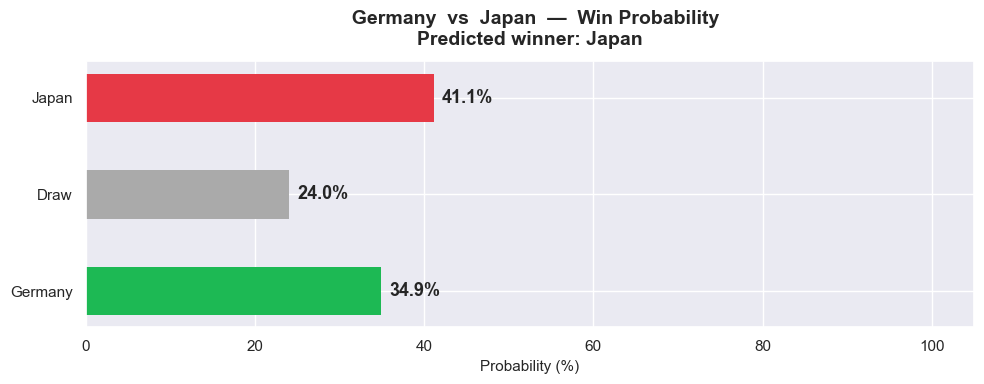

{'home_team': 'Germany',
 'away_team': 'Japan',
 'home_prob': np.float64(0.349),
 'draw_prob': np.float64(0.24),
 'away_prob': np.float64(0.411),
 'predicted_winner': 'Japan'}

In [63]:
plot_prediction('Germany', 'Japan', features_df)

## Group Stage Predicitons

In [64]:
features_df = pd.read_csv('data/team_features.csv')
fixtures_df = pd.read_csv('data/wc_2026_fixtures.csv')


group_matches = fixtures_df[fixtures_df['stage'] == 'GROUP_STAGE'].copy()
group_matches = group_matches.reset_index(drop=True)
print(f"Total group stage matches: {len(group_matches)}")
print(group_matches[['utcDate', 'home_name', 'away_name']].head(10))

Total group stage matches: 72
                utcDate      home_name               away_name
0  2026-06-11T19:00:00Z         Mexico            South Africa
1  2026-06-12T02:00:00Z    South Korea          Czech Republic
2  2026-06-12T19:00:00Z         Canada  Bosnia and Herzegovina
3  2026-06-13T01:00:00Z  United States                Paraguay
4  2026-06-13T19:00:00Z          Qatar             Switzerland
5  2026-06-13T22:00:00Z         Brazil                 Morocco
6  2026-06-14T01:00:00Z          Haiti                Scotland
7  2026-06-14T04:00:00Z      Australia                  Turkey
8  2026-06-14T17:00:00Z        Germany                 Curaçao
9  2026-06-14T20:00:00Z    Netherlands                   Japan


### 1. Generate Predictions and save CSV

In [65]:
results = []
skipped = []

for _, row in group_matches.iterrows():
    home = row['home_name']
    away = row['away_name']

    try:
        pred = predict_match(home, away, features_df)
        pred['stage'] = 'GROUP_STAGE'
        pred['date']  = row['utcDate']
        pred['actual_result'] = None   # fill this after each match
        pred['correct']       = None   # fill this after each match
        results.append(pred)

    except ValueError as e:
        # Team name not found in features_df
        skipped.append({'home': home, 'away': away, 'error': str(e)})

predictions_df = pd.DataFrame(results)

print(f"\nPredictions generated: {len(predictions_df)}")
print(f"Skipped (name mismatch): {len(skipped)}")

if skipped:
    print("\nFix these team names:")
    for s in skipped:
        print(f"  {s['home']} vs {s['away']} → {s['error']}")

⚠️  Curaçao: low confidence override applied — CONCACAF small nation — majority of wins vs Caribbean minnows, goal_diff inflated
⚠️  New Zealand: low confidence override applied — OFC qualifier — 10/11 matches vs Pacific minnows, 1 real result
⚠️  Curaçao: low confidence override applied — CONCACAF small nation — majority of wins vs Caribbean minnows, goal_diff inflated
⚠️  New Zealand: low confidence override applied — OFC qualifier — 10/11 matches vs Pacific minnows, 1 real result
⚠️  Curaçao: low confidence override applied — CONCACAF small nation — majority of wins vs Caribbean minnows, goal_diff inflated
⚠️  New Zealand: low confidence override applied — OFC qualifier — 10/11 matches vs Pacific minnows, 1 real result

Predictions generated: 72
Skipped (name mismatch): 0


In [66]:
predictions_df = predictions_df[[
    'date', 'stage', 'home_team', 'away_team',
    'home_prob', 'draw_prob', 'away_prob',
    'predicted_winner', 'actual_result', 'correct'
]]

predictions_df = predictions_df.sort_values('date').reset_index(drop=True)
predictions_df.to_csv('data/predictions.csv', index=False)

print("\nSaved: data/predictions.csv")
print(predictions_df.head(10).to_string())


Saved: data/predictions.csv
                   date        stage      home_team               away_team  home_prob  draw_prob  away_prob predicted_winner actual_result correct
0  2026-06-11T19:00:00Z  GROUP_STAGE         Mexico            South Africa      0.432       0.24      0.328           Mexico          None    None
1  2026-06-12T02:00:00Z  GROUP_STAGE    South Korea          Czech Republic      0.489       0.24      0.271      South Korea          None    None
2  2026-06-12T19:00:00Z  GROUP_STAGE         Canada  Bosnia and Herzegovina      0.590       0.24      0.170           Canada          None    None
3  2026-06-13T01:00:00Z  GROUP_STAGE  United States                Paraguay      0.594       0.24      0.166    United States          None    None
4  2026-06-13T19:00:00Z  GROUP_STAGE          Qatar             Switzerland      0.306       0.24      0.454      Switzerland          None    None
5  2026-06-13T22:00:00Z  GROUP_STAGE         Brazil                 Morocco      0.

## Accuracy Tracker Functions

### 1. Functions to check if the predictions were right and Update the Accuracy

In [67]:
def update_result(home_team, away_team, actual_winner):
    """
    Call this after a match finishes.
    actual_winner: exact team name, or 'Draw'

    Example usage:
        update_result('Argentina', 'Canada', 'Argentina')
        update_result('Spain', 'Morocco', 'Draw')
    """
    df = pd.read_csv('data/predictions.csv')

  
    df['actual_result'] = df['actual_result'].astype(object)
    df['correct']       = df['correct'].astype(object)

    mask = (df['home_team'] == home_team) & (df['away_team'] == away_team)

    if mask.sum() == 0:
        print(f"Match not found: {home_team} vs {away_team}")
        return

    df.loc[mask, 'actual_result'] = actual_winner
    df.loc[mask, 'correct'] = (
        df.loc[mask, 'predicted_winner'] == actual_winner
    )

    df.to_csv('data/predictions.csv', index=False)

    row = df[mask].iloc[0]
    status = "✅ CORRECT" if row['correct'] else "❌ WRONG"
    print(f"{status} — {home_team} vs {away_team}")
    print(f"  Predicted: {row['predicted_winner']}  |  Actual: {actual_winner}")


def accuracy_report():
    df = pd.read_csv('data/predictions.csv')

    df['actual_result'] = df['actual_result'].astype(object)
    df['correct']       = df['correct'].astype(object)

    played = df[df['actual_result'].notna()]

    if len(played) == 0:
        print("No results logged yet.")
        return

    correct  = (played['correct'] == True).sum()
    total    = len(played)
    accuracy = correct / total * 100

    print(f"\n{'='*40}")
    print(f"ACCURACY REPORT — {total} matches played")
    print(f"{'='*40}")
    print(f"Overall accuracy : {correct}/{total} = {accuracy:.1f}%")

    by_stage = played.groupby('stage').apply(
        lambda x: pd.Series({
            'correct':  (x['correct'] == True).sum(),
            'total':    len(x),
            'accuracy': f"{(x['correct'] == True).sum() / len(x) * 100:.1f}%"
        })
    )
    print(f"\nBy stage:\n{by_stage.to_string()}")

    wrong = df[df['correct'] == False][
        ['date', 'home_team', 'away_team', 'predicted_winner', 'actual_result']
    ]
    if len(wrong) > 0:
        print(f"\nWrong predictions ({len(wrong)}):")
        print(wrong.to_string(index=False))

    print(f"{'='*40}\n")

### 2. Log Results
- Run AFter Each Game
- Checks whether the prediction was correct
- Updates the Accuracy Accordingly

In [68]:

# Example usage after matches are played:
# update_result('Argentina', 'Canada', 'Argentina')
accuracy_report()

No results logged yet.


### 3. Full Prediction Table


In [69]:
df = pd.read_csv('data/predictions.csv')

print(f"\n{'MATCH':<35} {'HOME':>6}  {'DRAW':>6}  {'AWAY':>6}  WINNER")
print("─" * 75)

for _, row in df.iterrows():
    match_str = f"{row['home_team']} vs {row['away_team']}"
    print(
        f"{match_str:<35} "
        f"{row['home_prob']*100:>5.1f}%  "
        f"{row['draw_prob']*100:>5.1f}%  "
        f"{row['away_prob']*100:>5.1f}%  "
        f"{row['predicted_winner']}"
    )


MATCH                                 HOME    DRAW    AWAY  WINNER
───────────────────────────────────────────────────────────────────────────
Mexico vs South Africa               43.2%   24.0%   32.8%  Mexico
South Korea vs Czech Republic        48.9%   24.0%   27.1%  South Korea
Canada vs Bosnia and Herzegovina     59.0%   24.0%   17.0%  Canada
United States vs Paraguay            59.4%   24.0%   16.6%  United States
Qatar vs Switzerland                 30.6%   24.0%   45.4%  Switzerland
Brazil vs Morocco                    32.3%   24.0%   43.7%  Morocco
Haiti vs Scotland                    41.2%   24.0%   34.8%  Haiti
Australia vs Turkey                  37.0%   24.0%   39.0%  Turkey
Germany vs Curaçao                   60.1%   24.0%   15.9%  Germany
Netherlands vs Japan                 32.8%   24.0%   43.2%  Japan
Ivory Coast vs Ecuador               47.6%   24.0%   28.4%  Ivory Coast
Sweden vs Tunisia                    34.3%   24.0%   41.7%  Tunisia
Spain vs Cape Verde          

## Squad Value Analysis

### 1. Load Squad MArket Values from Dataset

In [70]:
os.makedirs('charts', exist_ok=True)

squads = pd.read_csv('data/squads.csv')   

squads['team'] = squads['team'].str.replace('Cura?o', 'Curaçao', regex=False)

squads['value_m'] = squads['squad_total_market_value_eur'] / 1_000_000

print(f"Teams loaded: {len(squads)}")
print(f"Columns: {list(squads.columns)}")
print(f"\nValue range: €{squads['value_m'].min():.1f}M → €{squads['value_m'].max():.1f}M")
print(f"Ranking range: {squads['fifa_rank_pre_tournament'].min()} → {squads['fifa_rank_pre_tournament'].max()}")
print(f"\nTop 5 by value:\n{squads[['team','value_m','fifa_rank_pre_tournament']].sort_values('value_m', ascending=False).head()}")

Teams loaded: 48
Columns: ['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before', 'winner', 'finalist', 'semi_finalist', 'quarter_finalist', 'value_m']

Value range: €5.3M → €1300.0M
Ranking range: 1 → 85

Top 5 by value:
       team  value_m  fifa_rank_pre_tournament
3   England   1300.0                         4
0    France   1290.0                         1
1     Spain   1150.0                         2
5    Brazil    932.0                         6
4  Portugal    841.0                         5


### 2. Plot Squad Values

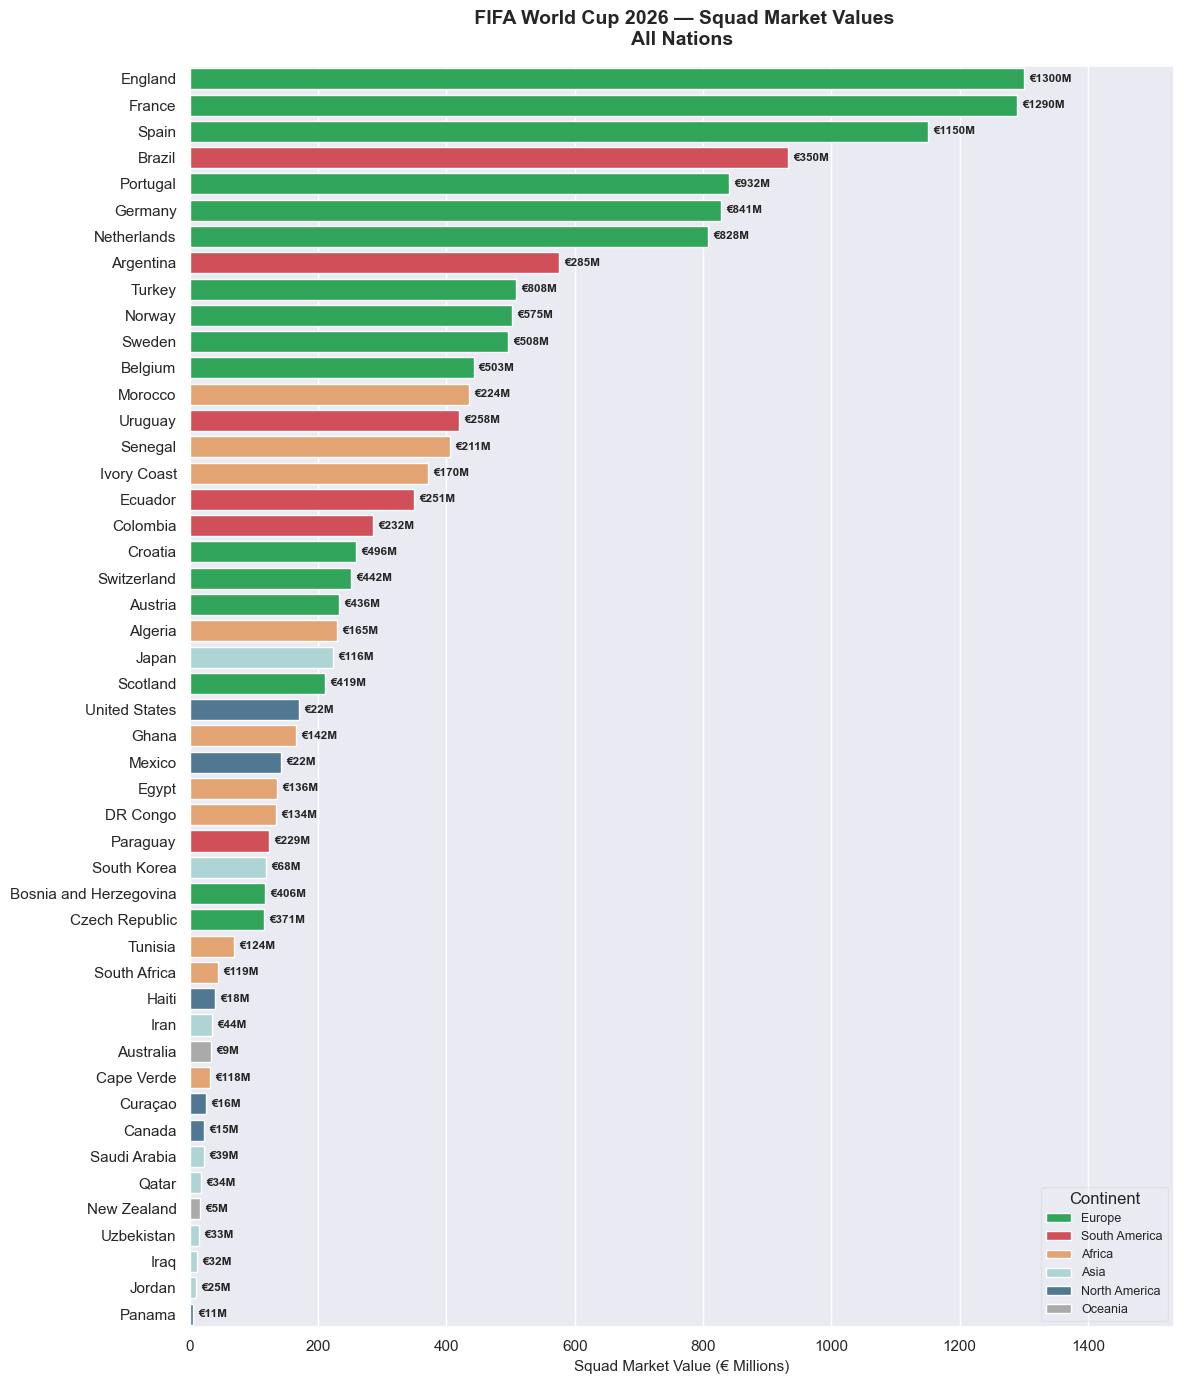

Saved: charts/squad_values_all.png


In [71]:
squads_sorted = squads.sort_values('value_m', ascending=False)

continent_colors = {
    'Europe':        '#1db954',
    'South America': '#e63946',
    'North America': '#457b9d',
    'Africa':        '#f4a261',
    'Asia':          '#a8dadc',
    'Oceania':       '#aaaaaa',
}

fig, ax = plt.subplots(figsize=(12, 14))

sns.barplot(
    data=squads_sorted,
    y='team',
    x='value_m',
    hue='continent',
    palette=continent_colors,
    dodge=False,
    ax=ax
)


for bar, (_, row) in zip(ax.patches, squads_sorted.iterrows()):
    ax.text(
        bar.get_width() + 8,
        bar.get_y() + bar.get_height() / 2,
        f'€{row["value_m"]:.0f}M',
        va='center',
        fontsize=8.5,
        fontweight='bold'
    )

ax.set_xlabel('Squad Market Value (€ Millions)', fontsize=11)
ax.set_ylabel('')
ax.set_title(
    ' FIFA World Cup 2026 — Squad Market Values\nAll Nations',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, squads_sorted['value_m'].max() * 1.18)
ax.legend(title='Continent', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('charts/squad_values_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/squad_values_all.png")

### 3. Value vs FIFA Ranking Scatter Plot with Regression Line

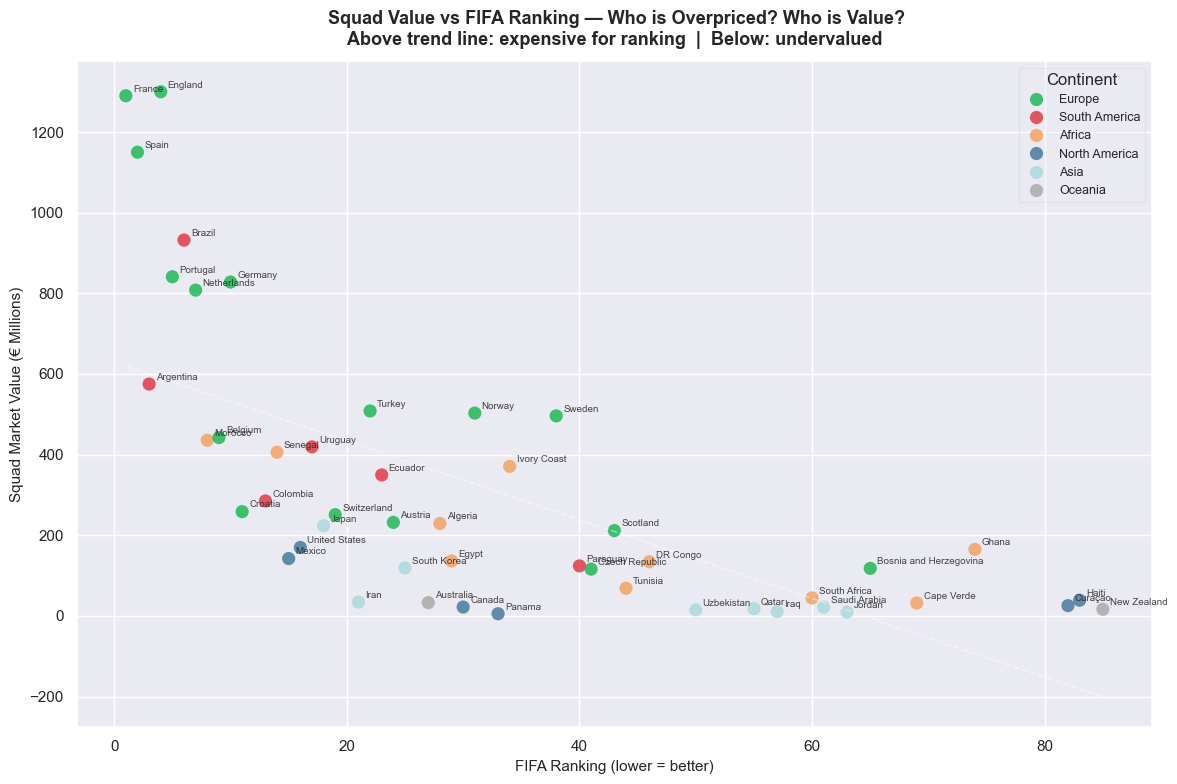

Saved: charts/value_vs_ranking.png


In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=squads,
    x='fifa_rank_pre_tournament',
    y='value_m',
    hue='continent',
    palette=continent_colors,
    s=90,
    alpha=0.85,
    edgecolor='none',
    ax=ax
)


for _, row in squads.iterrows():
    ax.annotate(
        row['team'],
        (row['fifa_rank_pre_tournament'], row['value_m']),
        textcoords='offset points',
        xytext=(5, 3),
        fontsize=7,
        alpha=0.85
    )

sns.regplot(
    data=squads,
    x='fifa_rank_pre_tournament',
    y='value_m',
    scatter=False,             
    line_kws={'color': 'white', 'linewidth': 1.2, 'linestyle': '--', 'alpha': 0.4},
    ci=None,
    ax=ax
)

ax.set_xlabel('FIFA Ranking (lower = better)', fontsize=11)
ax.set_ylabel('Squad Market Value (€ Millions)', fontsize=11)
ax.set_title(
    ' Squad Value vs FIFA Ranking — Who is Overpriced? Who is Value?\n'
    'Above trend line: expensive for ranking  |  Below: undervalued',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(title='Continent', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('charts/value_vs_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/value_vs_ranking.png")

### 4. Compute and Plot Underdog Index
- Underdog index: high FIFA ranking relative to low squad cost
- Formula: (max_rank - team_rank) / value_m, normalised to 0-100

In [73]:
import numpy as np
z = np.polyfit(squads['fifa_rank_pre_tournament'], squads['value_m'], 1)
p = np.poly1d(z)

squads['underdog_index'] = (
    (squads['fifa_rank_pre_tournament'].max() - squads['fifa_rank_pre_tournament'])
    / squads['value_m']
)
squads['underdog_index'] = (
    squads['underdog_index'] / squads['underdog_index'].max() * 100
).round(1)

squads['expected_value'] = p(squads['fifa_rank_pre_tournament'])
squads['value_gap']      = squads['value_m'] - squads['expected_value']

print("Columns added: underdog_index, expected_value, value_gap")
print(squads[['team', 'value_m', 'fifa_rank_pre_tournament', 'underdog_index']].sort_values('underdog_index', ascending=False).head(10))

Columns added: underdog_index, expected_value, value_gap
            team  value_m  fifa_rank_pre_tournament  underdog_index
28        Panama     5.30                        33           100.0
38          Iraq    10.70                        57            26.7
26        Canada    21.88                        30            25.6
41        Jordan     9.30                        63            24.1
36    Uzbekistan    14.85                        50            24.0
18          Iran    34.25                        21            19.0
23     Australia    32.85                        27            18.0
37         Qatar    18.00                        55            17.0
40  Saudi Arabia    21.80                        61            11.2
34       Tunisia    68.45                        44             6.1


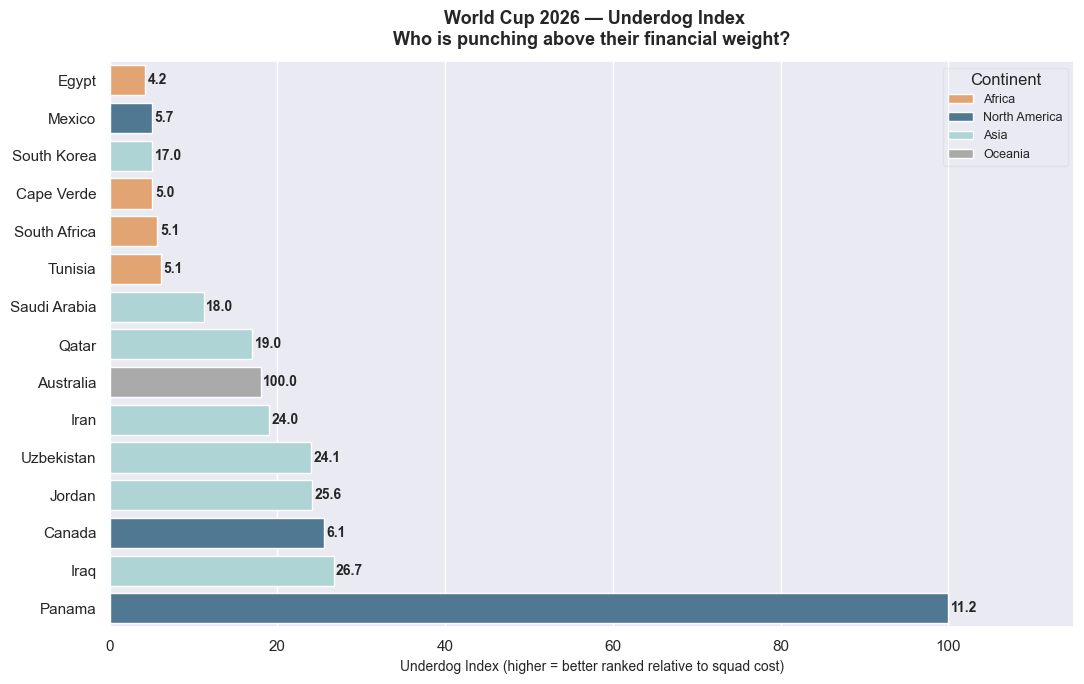

Saved: charts/underdog_index.png


In [74]:
top_underdogs = squads.sort_values('underdog_index', ascending=False).head(15)
top_underdogs_plot = top_underdogs.sort_values('underdog_index', ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_underdogs_plot,
    y='team',
    x='underdog_index',
    hue='continent',
    palette=continent_colors,
    dodge=False,
    ax=ax
)

for bar, (_, row) in zip(ax.patches, top_underdogs_plot.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{row["underdog_index"]:.1f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('Underdog Index (higher = better ranked relative to squad cost)', fontsize=10)
ax.set_ylabel('')
ax.set_title(
    ' World Cup 2026 — Underdog Index\nWho is punching above their financial weight?',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlim(0, top_underdogs_plot['underdog_index'].max() * 1.15)
ax.legend(title='Continent', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('charts/underdog_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/underdog_index.png")

## Charts for Post 1

### 1. Predictions Table

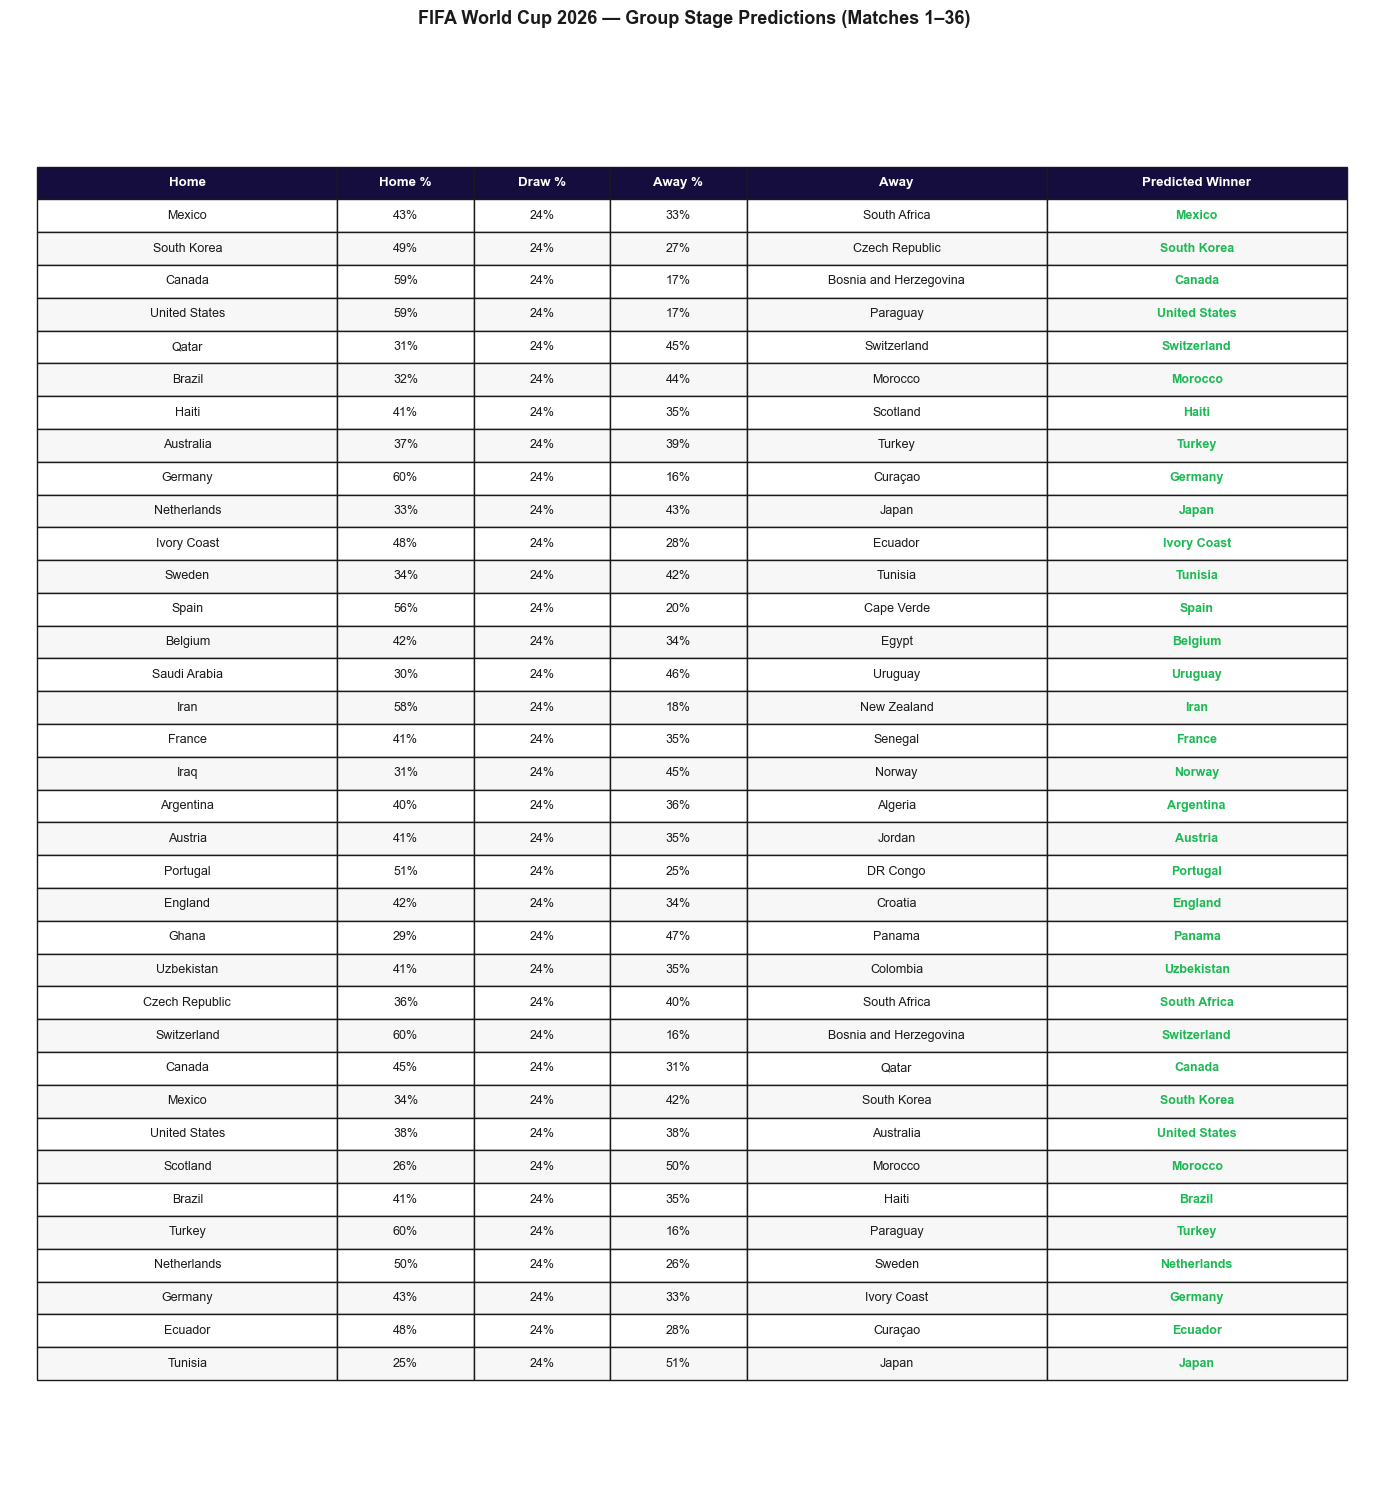

Saved: charts/post1_predictions_table_1.png


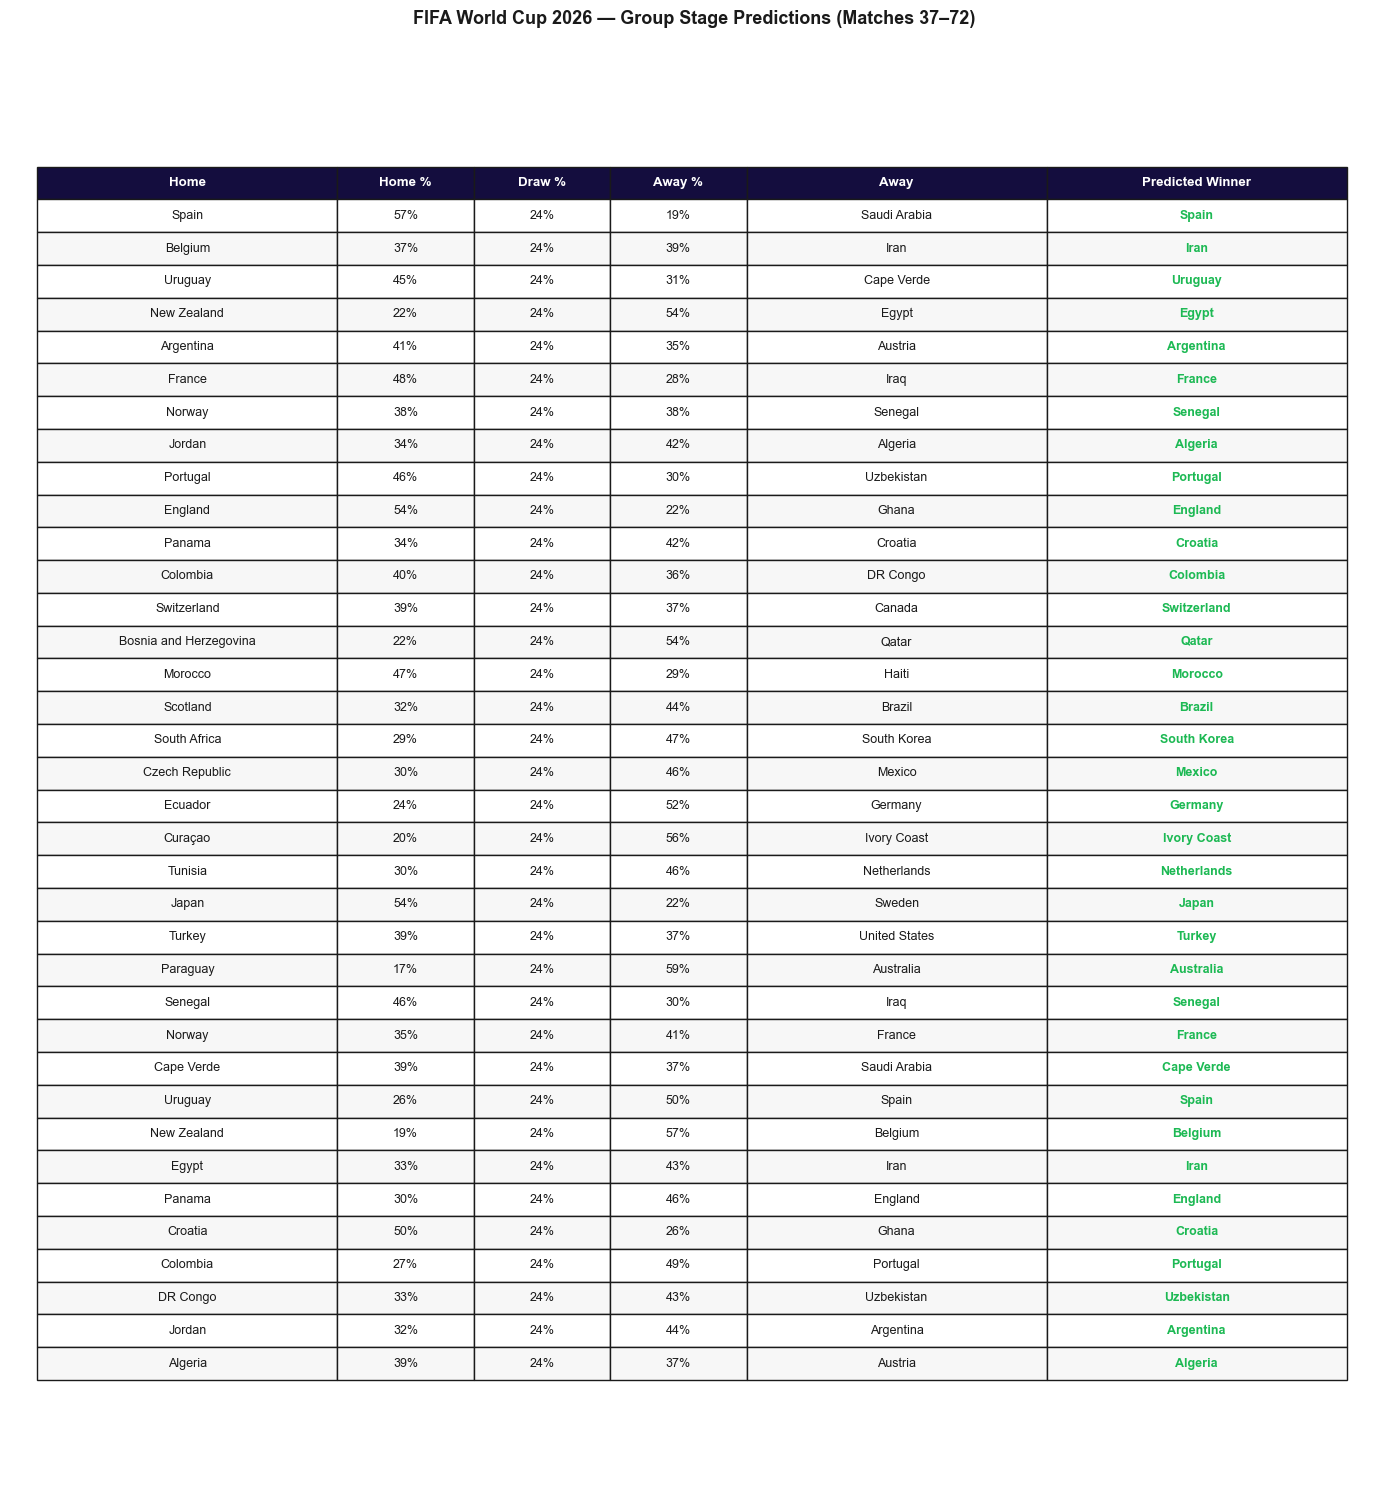

Saved: charts/post1_predictions_table_2.png


In [75]:
def plot_predictions_table(df_slice, filename, title_suffix=''):
    rows = []
    for _, r in df_slice.iterrows():
        rows.append([
            r['home_team'],
            f"{r['home_prob']*100:.0f}%",
            f"{r['draw_prob']*100:.0f}%",
            f"{r['away_prob']*100:.0f}%",
            r['away_team'],
            r['predicted_winner']
        ])

    col_labels = ['Home', 'Home %', 'Draw %', 'Away %', 'Away', 'Predicted Winner']

    fig, ax = plt.subplots(figsize=(14, len(rows) * 0.38 + 1.5))
    ax.axis('off')
    fig.patch.set_facecolor('white')

    table = ax.table(
        cellText=rows,
        colLabels=col_labels,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)


    col_widths = [0.22, 0.10, 0.10, 0.10, 0.22, 0.22]
    for j, width in enumerate(col_widths):
        for i in range(len(rows) + 1):
            table[i, j].set_width(width)


    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#140d3e")
        table[0, j].set_text_props(color='white', fontweight='bold', fontsize=9.5)


    for i in range(1, len(rows) + 1):
        bg = '#f7f7f7' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            table[i, j].set_facecolor(bg)
            table[i, j].set_text_props(color='#1a1a1a')

        # Predicted winner column — green text, bold
        table[i, 5].set_text_props(
            color='#1db954', fontweight='bold'
        )

    ax.set_title(
        f' FIFA World Cup 2026 — Group Stage Predictions {title_suffix}\n'
        ,
        fontsize=13, fontweight='bold', pad=7, color='#1a1a1a'
    )

    plt.tight_layout()
    plt.savefig(f'charts/{filename}', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f"Saved: charts/{filename}")

half = len(group_df) // 2
plot_predictions_table(
    group_df.iloc[:half],
    'post1_predictions_table_1.png',
    '(Matches 1–36)'
)
plot_predictions_table(
    group_df.iloc[half:],
    'post1_predictions_table_2.png',
    '(Matches 37–72)'
)

### 2. Predicted Upsets

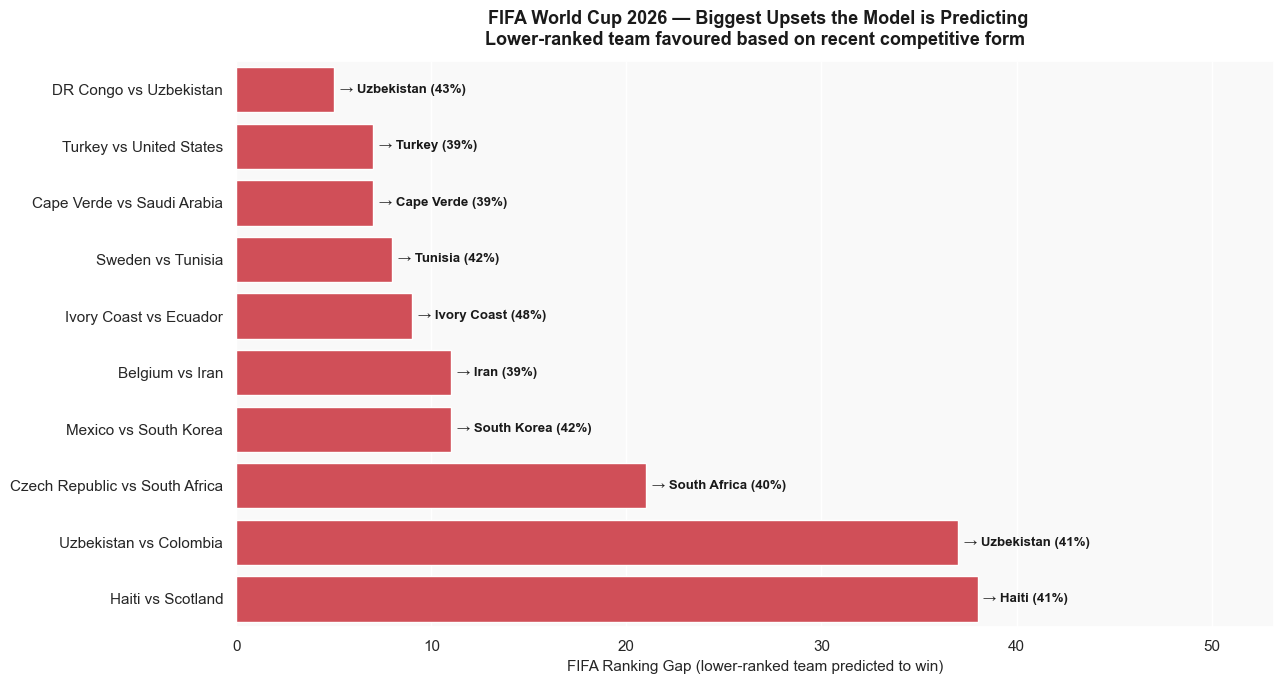

Saved: charts/post1_predicted_upsets.png


In [76]:
upsets = []

for _, r in group_df.iterrows():
    home_row = features_df[features_df['team'] == r['home_team']]
    away_row = features_df[features_df['team'] == r['away_team']]

    if home_row.empty or away_row.empty:
        continue

    home_rank = home_row.iloc[0]['fifa_ranking']
    away_rank = away_row.iloc[0]['fifa_ranking']

    if r['predicted_winner'] == r['away_team'] and away_rank > home_rank:
        upsets.append({
            'match':            f"{r['home_team']} vs {r['away_team']}",
            'predicted_winner': r['predicted_winner'],
            'rank_diff':        int(away_rank - home_rank),
            'winner_prob':      round(r['away_prob'] * 100, 1)
        })
    elif r['predicted_winner'] == r['home_team'] and home_rank > away_rank:
        upsets.append({
            'match':            f"{r['home_team']} vs {r['away_team']}",
            'predicted_winner': r['predicted_winner'],
            'rank_diff':        int(home_rank - away_rank),
            'winner_prob':      round(r['home_prob'] * 100, 1)
        })

upsets_df = (pd.DataFrame(upsets)
               .sort_values('rank_diff', ascending=False)
               .head(10)
               .sort_values('rank_diff', ascending=True))

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f9f9f9')

sns.barplot(
    data=upsets_df,
    y='match',
    x='rank_diff',
    color='#e63946',
    ax=ax
)

for bar, (_, row) in zip(ax.patches, upsets_df.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"→ {row['predicted_winner']} ({row['winner_prob']:.0f}%)",
        va='center',
        fontsize=9.5,
        fontweight='bold',
        color='#1a1a1a'
    )

ax.set_xlabel('FIFA Ranking Gap (lower-ranked team predicted to win)', fontsize=11)
ax.set_ylabel('')
ax.set_title(
    ' FIFA World Cup 2026 — Biggest Upsets the Model is Predicting\n'
    'Lower-ranked team favoured based on recent competitive form',
    fontsize=13, fontweight='bold', pad=12, color='#1a1a1a'
)
ax.set_xlim(0, upsets_df['rank_diff'].max() * 1.4)

plt.tight_layout()
plt.savefig('charts/post1_predicted_upsets.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: charts/post1_predicted_upsets.png")